<h2 style="text-align:center; font-size:18px; font-weight:bold;"> FLIGHT PRICE ANALYSIS AND PREDICTION USING DATA ANALYTICS </h1> <h2 style="font-weight:bold;">INTRODUCTION</h1> <p style="font-size:16px;"> Flight ticket prices vary based on several factors such as airline, flight number, source and destination cities, departure and arrival time, number of stops, travel class, duration, and days left before departure. </p> <p style="font-size:16px;"> In this project, flight data is analyzed using data analytics techniques to identify patterns affecting ticket prices. </p> <p style="font-size:16px;"> A regression model is developed to predict flight prices using features like airline, flight, source_city, departure_time, stops, arrival_time, destination_city, class, duration, and days_left. </p>



<h2 style="font-weight:bold;">TOOLS AND LIBRARIES USED</h2> <p style="font-size:16px;"> The following Python libraries were used for data analysis, preprocessing, visualization, and model building: </p> <ul style="font-size:16px;"> <li><b>Pandas</b> – Used for data manipulation and analysis.</li> <li><b>NumPy</b> – Used for numerical computations.</li> <li><b>Matplotlib</b> – Used for data visualization.</li> <li><b>Seaborn</b> – Used for advanced statistical visualizations.</li> <li><b>Scikit-learn (sklearn)</b> – Used for machine learning tasks, including preprocessing, model building, and evaluation.</li> </ul> <p style="font-size:16px;"> Specific modules from Scikit-learn include OneHotEncoder and ColumnTransformer for handling categorical data, train_test_split for splitting the dataset, LinearRegression and PolynomialFeatures for model building, StandardScaler for feature scaling, and metrics for evaluating model performance. </p>

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn import metrics

<h2 style="font-weight:bold;">LOADING THE DATASET</h2>

In [ ]:
df = pd.read_csv(r"Clean_Dataset.csv")
print(df.head(8))

   Unnamed: 0   airline   flight source_city departure_time stops  \
0           0  SpiceJet  SG-8709       Delhi        Evening  zero   
1           1  SpiceJet  SG-8157       Delhi  Early_Morning  zero   
2           2   AirAsia   I5-764       Delhi  Early_Morning  zero   
3           3   Vistara   UK-995       Delhi        Morning  zero   
4           4   Vistara   UK-963       Delhi        Morning  zero   
5           5   Vistara   UK-945       Delhi        Morning  zero   
6           6   Vistara   UK-927       Delhi        Morning  zero   
7           7   Vistara   UK-951       Delhi      Afternoon  zero   

    arrival_time destination_city    class  duration  days_left  price  
0          Night           Mumbai  Economy      2.17          1   5953  
1        Morning           Mumbai  Economy      2.33          1   5953  
2  Early_Morning           Mumbai  Economy      2.17          1   5956  
3      Afternoon           Mumbai  Economy      2.25          1   5955  
4        Morn

<h2 style="font-weight:bold;">DATA UNDERSTANDING</h2>

<p style="font-size:16px;">
In this step, we explore the structure and basic information of the dataset to understand its features, data types, and overall composition.
</p>

In [88]:
df.shape

(300153, 12)

In [89]:
df.columns

Index(['Unnamed: 0', 'airline', 'flight', 'source_city', 'departure_time',
       'stops', 'arrival_time', 'destination_city', 'class', 'duration',
       'days_left', 'price'],
      dtype='object')

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [91]:
df.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


<h2 style="font-weight:bold;">DATA CLEANING</h2>

<p style="font-size:16px;">
In this step, we clean the dataset by removing unnecessary columns and checking for missing or inconsistent values to ensure data quality.
</p>

Step 1: Remove unnecessary column

In [92]:
df.drop(columns=['Unnamed: 0'], inplace=True)
df.drop(columns=['flight'], axis=1, inplace=True)

Step 2: Check missing values

In [93]:
df.isnull().sum()

airline             0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

<p style="font-size:16px;">
There are no missing values in the dataset.
</p>

Step 3: Check duplicates 

In [94]:
df.duplicated().sum()

np.int64(2213)

<h2 style="font-weight:bold;">EXPLORATORY DATA ANALYSIS</h2> <p style="font-size:16px;"> Exploratory Data Analysis (EDA) is the process of analyzing and understanding the dataset to discover patterns, relationships, and insights. In this step, statistical methods and visualizations are used to examine how features such as airline, source and destination cities, departure and arrival time, class, number of stops, duration, and days left before departure influence flight ticket prices. </p> <p style="font-size:16px;"> EDA helps in identifying important variables, detecting outliers, and gaining meaningful insights before building a machine learning model. </p>

Q1. What is the overall distribution of ticket prices?

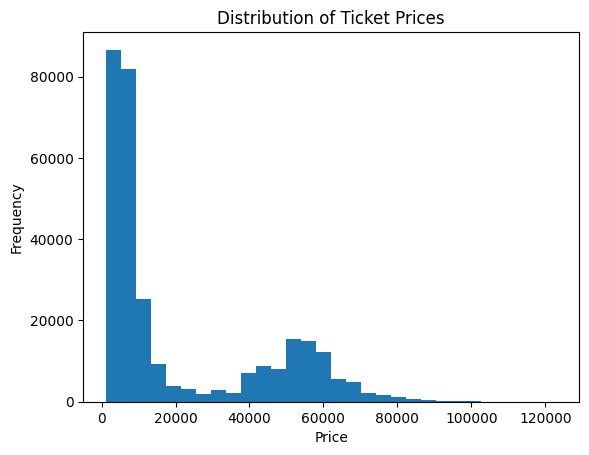

In [95]:
plt.hist(df['price'],bins=30)
plt.title("Distribution of Ticket Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()



The ticket price distribution is right-skewed, with most flights in the lower to mid-price range and a few high-priced outliers. The multiple peaks indicate different pricing segments, such as budget and premium flights.

Q2. What are the most common airlines in the dataset?

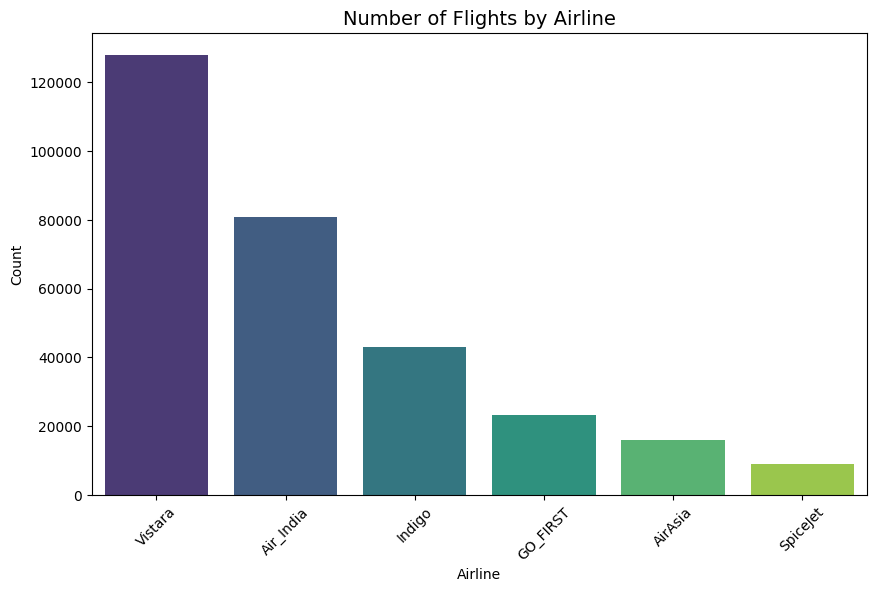

In [96]:
airline_counts = df['airline'].value_counts().reset_index()
airline_counts.columns = ['Airline', 'Count']
plt.figure(figsize=(10, 6))
sns.barplot(x='Airline', y='Count', data=airline_counts, palette='viridis', hue='Airline', legend=False)
plt.title("Number of Flights by Airline", fontsize=14)
plt.xlabel("Airline")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


The bar chart illustrates the number of flights operated by each airline in the dataset. It can be observed that certain airlines operate a significantly higher number of flights compared to others, indicating a stronger presence in the market. This uneven distribution highlights that the dataset is dominated by a few airlines, which may influence further analysis and model building.

Q3. How do average ticket prices differ between airlines?

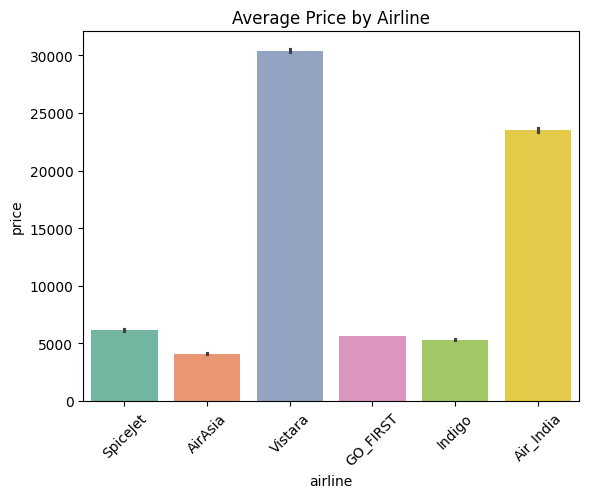

In [97]:
sns.barplot(
    x='airline',
    y='price',
    data=df,
    hue='airline',
    palette='Set2',
    legend=False
)

plt.title("Average Price by Airline")
plt.xticks(rotation=45)
plt.show()


The bar chart represents the average ticket price for each airline. It can be observed that there is a clear variation in pricing among different airlines. Some airlines have higher average ticket prices, indicating premium services, while others offer relatively lower prices, suggesting budget-friendly options. This shows that the choice of airline is an important factor influencing ticket price.

Q4. What is the effect of number of stops on ticket price?

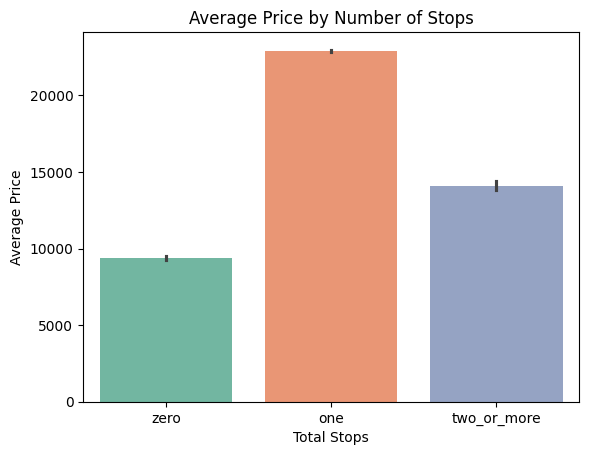

In [98]:
sns.barplot(x='stops', y='price', data=df, palette='Set2',hue='stops',legend=False)
plt.title("Average Price by Number of Stops")
plt.xlabel("Total Stops")
plt.ylabel("Average Price")
plt.show()


The bar chart shows the average ticket price based on the number of stops. It can be observed that ticket prices vary across different stop categories. Flights with more stops tend to have different pricing patterns compared to non-stop flights, indicating that the number of stops plays a significant role in determining ticket prices.

Q5. How is flight duration distributed?

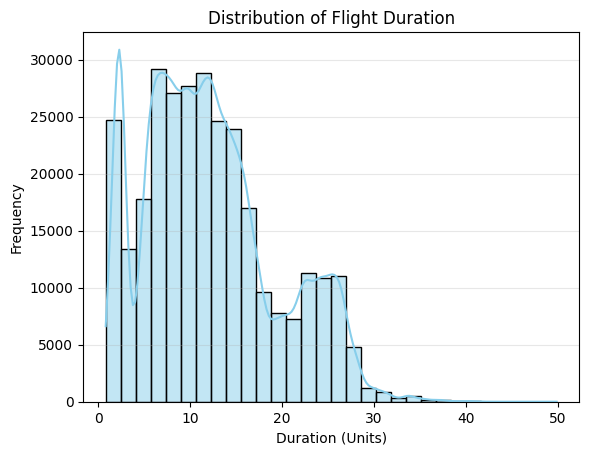

In [99]:
sns.histplot(df['duration'], bins=30, kde=True, color='skyblue')
plt.grid(axis='y', alpha=0.3)
plt.title("Distribution of Flight Duration")
plt.xlabel("Duration (Units)")
plt.ylabel("Frequency")
plt.show()

This histogram shows how flight durations are distributed in the dataset. Most flights have durations between 5 to 15 units, indicating that short to medium-haul flights are more common. The distribution is right-skewed, meaning there are fewer flights with very long durations. The KDE curve highlights the overall pattern and density of the data.

Q6. Which routes (source to destination) are most frequent?

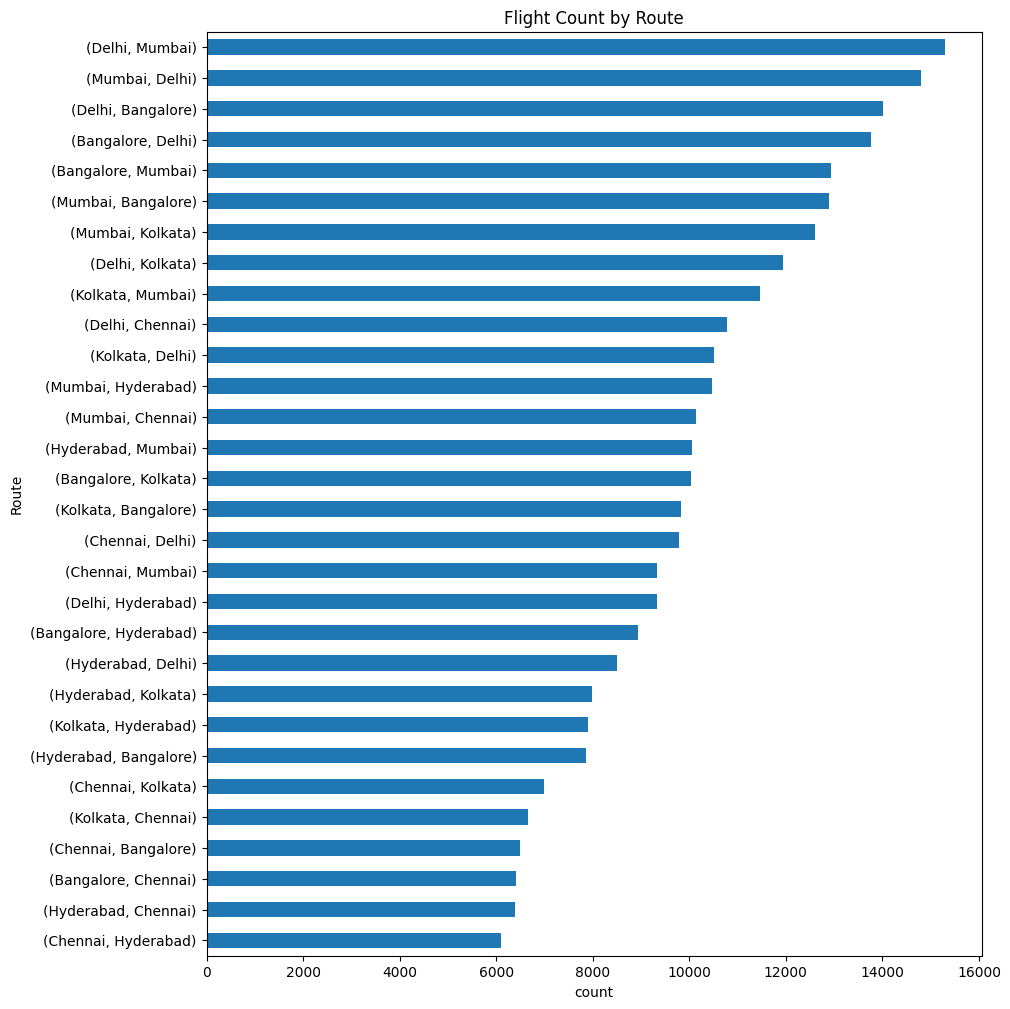

In [100]:
df.groupby(['source_city','destination_city']).size().sort_values().plot(kind='barh',figsize=(10,12))

plt.title("Flight Count by Route")
plt.xlabel("count")
plt.ylabel("Route")
plt.show()

The bar chart shows the number of flights between different city pairs. Routes like Delhi → Mumbai and Mumbai → Delhi are the most frequent, indicating high demand between major metropolitan cities. Other busy routes include Delhi ↔ Bangalore and Mumbai ↔ Bangalore. Overall, metro-to-metro routes dominate the dataset, while routes involving cities like Hyderabad and Chennai have comparatively fewer flights.

Q7 Which routes have the highest average ticket prices?

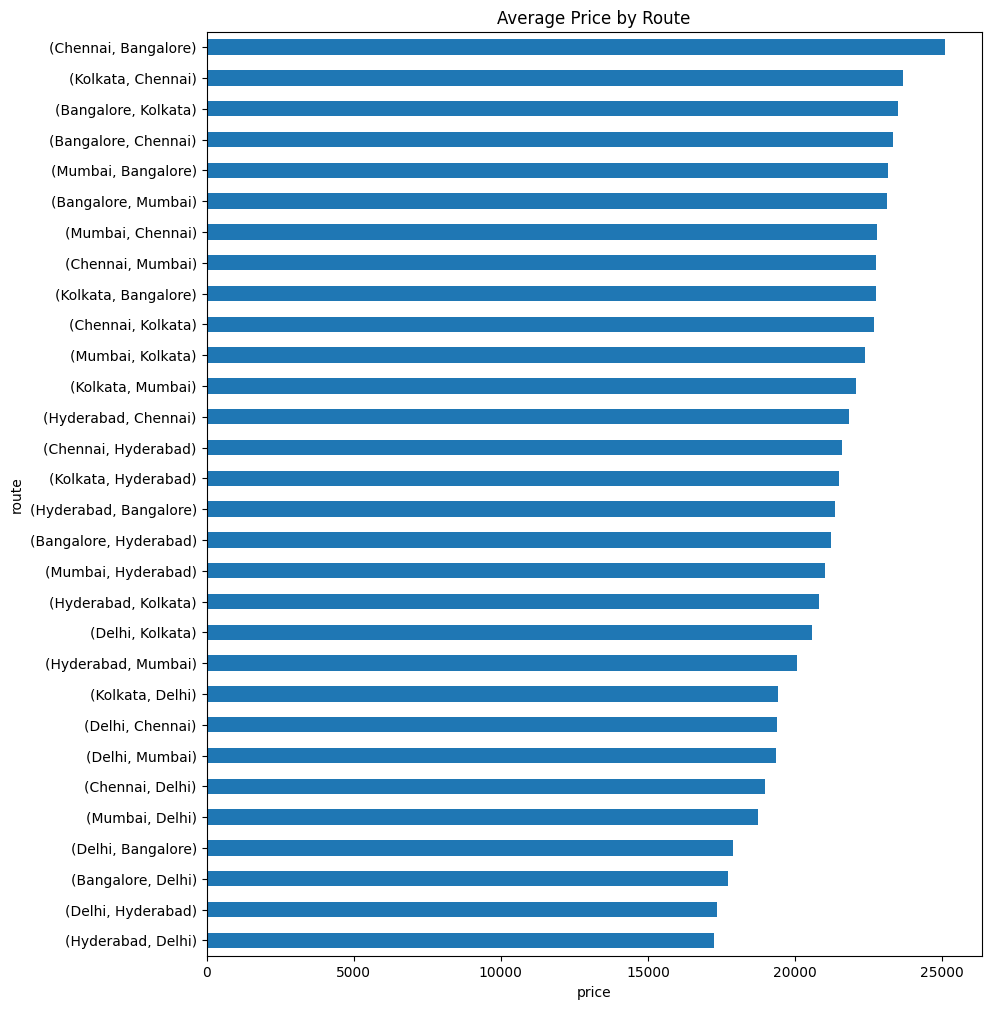

In [101]:
df.groupby(['source_city','destination_city'])['price'].mean().sort_values().plot(kind='barh',figsize=(10,12))

plt.title("Average Price by Route")
plt.xlabel("price")
plt.ylabel("route")
plt.show()

The chart shows that routes like Chennai → Bangalore, Kolkata → Chennai, and Bangalore → Kolkata have the highest average ticket prices. In contrast, routes such as Hyderabad → Delhi and Delhi → Hyderabad have relatively lower average prices. This indicates that pricing varies significantly based on route demand, distance, and connectivity.

Q8 How do ticket prices vary across different travel classes?

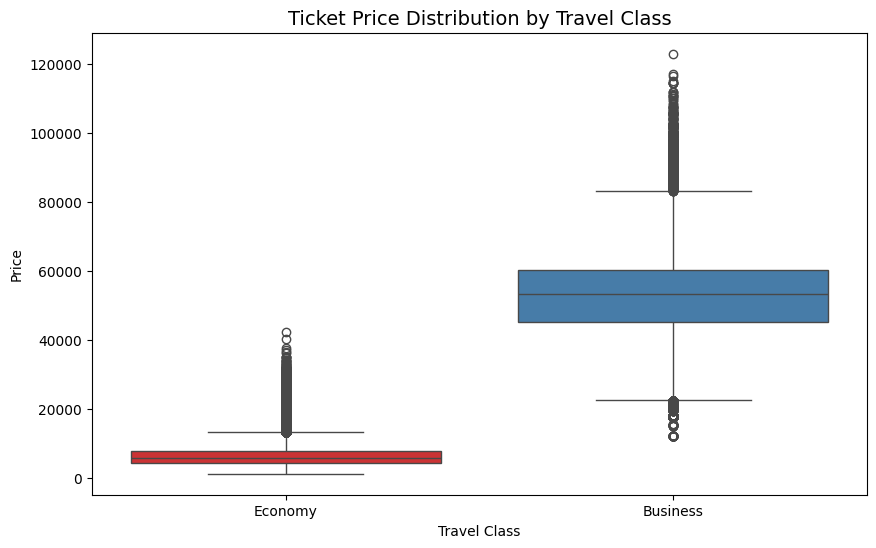

In [102]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='class', y='price', data=df, palette='Set1', hue='class', legend=False)

plt.title("Ticket Price Distribution by Travel Class", fontsize=14)
plt.xlabel("Travel Class")
plt.ylabel("Price")
plt.show()

The boxplot shows a significant difference in ticket prices between travel classes. Business class tickets are much more expensive than economy class, with a higher median price and wider price range. Economy class prices are lower and more concentrated, while business class shows greater variability and more outliers.

Q9 Does the time of day affect the ticket price?

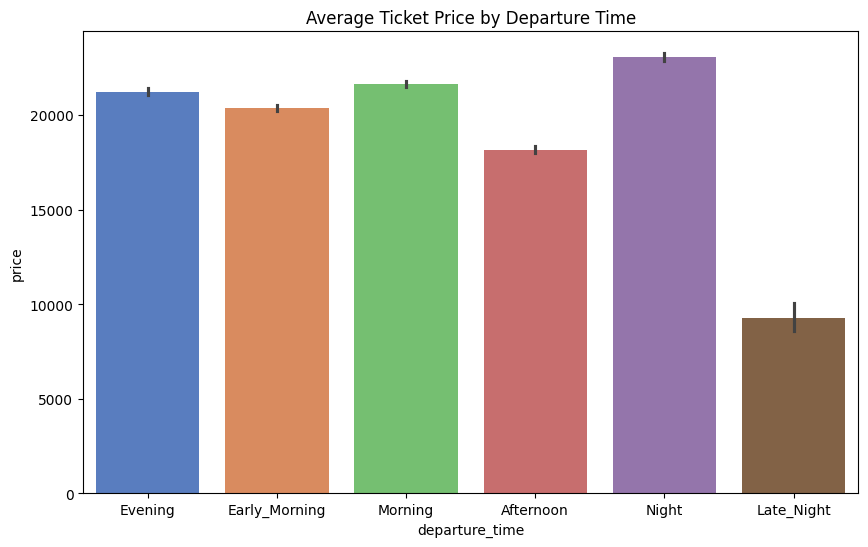

In [103]:
plt.figure(figsize=(10,6))
sns.barplot(x='departure_time', y='price', data=df, palette='muted', hue='departure_time', legend=False)
plt.title("Average Ticket Price by Departure Time")
plt.show()

The bar chart shows that ticket prices vary based on the time of departure. Flights during night and evening tend to have slightly higher average prices, while early morning flights are generally cheaper. This suggests that demand and convenience play a role in pricing.

Q10 Is there a relationship between the number of stops and flight duration?

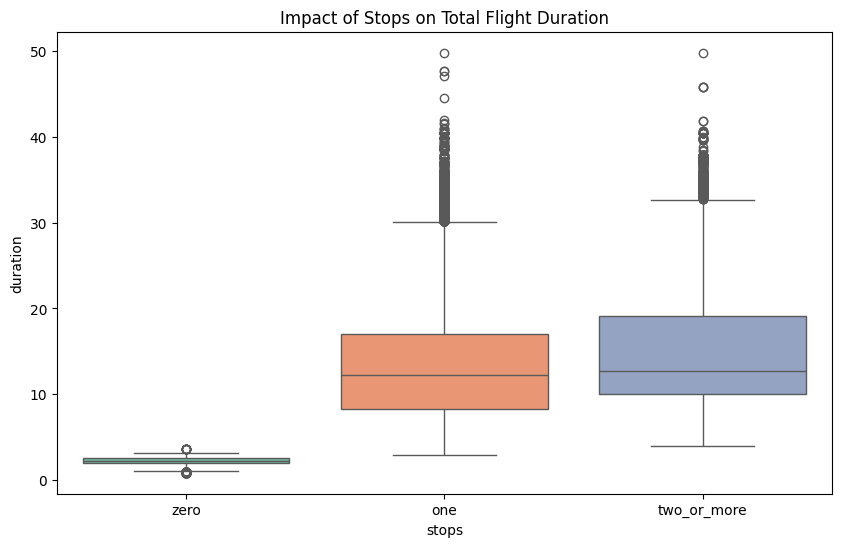

In [104]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='stops', y='duration', data=df, palette='Set2', hue='stops', legend=False)
plt.title("Impact of Stops on Total Flight Duration")
plt.show()

While adding a stop drastically increases travel time, the difference between one stop and two+ stops is less dramatic than the jump from zero to one. This suggests that the first layover adds the most significant bulk of time to a journey.

<h2 style="font-weight:bold;">FEATURE ENGINEERING AND DATA PREPROCESSING</h2> <p style="font-size:16px;"> In this step, the dataset is prepared for model building by converting categorical features into numerical format and selecting relevant variables. </p> <p style="font-size:16px;"> The categorical columns such as airline, source_city, departure_time, arrival_time, destination_city, class, and stops are identified and transformed into numerical form using One-Hot Encoding. This is done using ColumnTransformer along with OneHotEncoder to ensure that the machine learning model can process categorical data effectively. </p> <p style="font-size:16px;"> The numerical features used in the model include duration and days_left. These features are directly used for training the model after preprocessing. </p> <p style="font-size:16px;"> This preprocessing step ensures that all input features are in a suitable format for regression modeling. </p>

In [105]:
cat_cols = ['airline', 'source_city', 'departure_time',
            'arrival_time', 'destination_city', 'class','stops']

num_cols = ['duration', 'days_left']

preprocessor = ColumnTransformer(
    transformers=[
        ('encoding', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

<h2 style="font-weight:bold;">FEATURE SELECTION</h2> <p style="font-size:16px;"> The dataset is divided into input features (X) and target variable (y). All columns except price are taken as input features, and price is used as the target variable for prediction. </p>

In [106]:
x = df.drop('price', axis=1)
y = df['price']
print(x)
print(y)


         airline source_city departure_time stops   arrival_time  \
0       SpiceJet       Delhi        Evening  zero          Night   
1       SpiceJet       Delhi  Early_Morning  zero        Morning   
2        AirAsia       Delhi  Early_Morning  zero  Early_Morning   
3        Vistara       Delhi        Morning  zero      Afternoon   
4        Vistara       Delhi        Morning  zero        Morning   
...          ...         ...            ...   ...            ...   
300148   Vistara     Chennai        Morning   one        Evening   
300149   Vistara     Chennai      Afternoon   one          Night   
300150   Vistara     Chennai  Early_Morning   one          Night   
300151   Vistara     Chennai  Early_Morning   one        Evening   
300152   Vistara     Chennai        Morning   one        Evening   

       destination_city     class  duration  days_left  
0                Mumbai   Economy      2.17          1  
1                Mumbai   Economy      2.33          1  
2           

<h2 style="font-weight:bold;">TRAIN-TEST SPLIT</h2>

<p style="font-size:16px;">
The dataset is divided into training and testing sets using train_test_split. The training data is used to train the model, while the testing data is used to evaluate its performance.
</p>

In [107]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

<h2 style="font-weight:bold;">DATA PREPROCESSING</h2>

<p style="font-size:16px;">
The training data is transformed using the preprocessor, where categorical features are converted into numerical format using One-Hot Encoding. The same transformation is applied to the test data to ensure consistency.
</p>

In [108]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [109]:
print(x_train)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1721662 stored elements and shape (240122, 30)>
  Coords	Values
  (0, 0)	1.0
  (0, 8)	1.0
  (0, 18)	1.0
  (0, 20)	1.0
  (0, 25)	1.0
  (0, 28)	19.42
  (0, 29)	6.0
  (1, 2)	1.0
  (1, 6)	1.0
  (1, 19)	1.0
  (1, 20)	1.0
  (1, 25)	1.0
  (1, 26)	1.0
  (1, 28)	7.0
  (1, 29)	13.0
  (2, 0)	1.0
  (2, 8)	1.0
  (2, 20)	1.0
  (2, 28)	21.17
  (2, 29)	44.0
  (3, 4)	1.0
  (3, 7)	1.0
  (3, 14)	1.0
  (3, 15)	1.0
  (3, 25)	1.0
  :	:
  (240118, 20)	1.0
  (240118, 28)	25.42
  (240118, 29)	7.0
  (240119, 0)	1.0
  (240119, 8)	1.0
  (240119, 14)	1.0
  (240119, 18)	1.0
  (240119, 24)	1.0
  (240119, 25)	1.0
  (240119, 28)	13.67
  (240119, 29)	29.0
  (240120, 1)	1.0
  (240120, 8)	1.0
  (240120, 19)	1.0
  (240120, 22)	1.0
  (240120, 25)	1.0
  (240120, 28)	8.33
  (240120, 29)	39.0
  (240121, 0)	1.0
  (240121, 8)	1.0
  (240121, 18)	1.0
  (240121, 21)	1.0
  (240121, 25)	1.0
  (240121, 28)	20.17
  (240121, 29)	17.0


<h2 style="font-weight:bold;">MODEL BUILDING AND COMPARISON</h2>

<p style="font-size:16px;">
In this project, both Linear Regression and Polynomial Regression models are used to predict flight ticket prices. The Linear Regression model captures the linear relationship between features and price, while Polynomial Regression is used to model non-linear relationships.
</p>

<p style="font-size:16px;">
Both models are trained using the training dataset, and predictions are made on the test dataset. The performance of the models is then compared to identify the more accurate approach.
</p>

<h2 style="font-weight:bold;">LINEAR REGRESSION</h2>

<p style="font-size:16px;">
The Linear Regression model is trained using the training data, and predictions are made on the test data.
</p>

In [110]:
regressor = LinearRegression()
regressor.fit(x_train,y_train)
y_pred = regressor.predict(x_test)

<h2 style="font-weight:bold;">MODEL EVALUATION</h2>

<p style="font-size:16px;">
The performance of the model is evaluated using metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE),Root Mean Squared Error (RMSE) and r_2 score. These metrics help in measuring the accuracy of the predicted flight prices compared to the actual values.
</p>

In [111]:
print('Mean Absolute Error:',metrics.mean_absolute_error(y_test,y_pred))
print('Mean Squared Error:',metrics.mean_squared_error(y_test,y_pred))
print('Mean:',df.iloc[:,-1].mean())
print('Root Mean Squared Error:',np.sqrt(metrics.mean_squared_error(y_test,y_pred)))
score = metrics.r2_score(y_test,y_pred)
print('r2_score is ',score*100,'%')

Mean Absolute Error: 4553.346038920676
Mean Squared Error: 45720847.91959776
Mean: 20889.660523133203
Root Mean Squared Error: 6761.719302041291
r2_score is  91.13047135393123 %


<h2 style="font-weight:bold;">FEATURE SCALING</h2>

<p style="font-size:16px;">
Feature scaling is applied using StandardScaler to normalize the input features. This step ensures that all features are on a similar scale, which improves the performance of the Polynomial Regression model.
</p>

In [112]:
scaler = StandardScaler(with_mean=False)
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

<h2 style="font-weight:bold;">POLYNOMIAL FEATURE TRANSFORMATION</h2>

<p style="font-size:16px;">
Polynomial features are generated using PolynomialFeatures with degree 2. This transformation allows the model to capture non-linear relationships between the input features and the target variable.
</p>

In [113]:
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

model = LinearRegression()
model.fit(x_train_poly,y_train)
y_prediction = model.predict(x_test_poly)

<h2 style="font-weight:bold;">RESULTS</h2>


<p style="font-size:16px;">
The Polynomial Regression model is evaluated using performance metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R² score. These metrics are used to measure the accuracy of the model in predicting flight ticket prices.
</p>

<p style="font-size:16px;">
The obtained results indicate how well the model fits the data and captures non-linear relationships between features and the target variable.
</p>

In [115]:
print('Mean Absolute Error:',metrics.mean_absolute_error(y_test,y_prediction))
print('Mean Squared Error:',metrics.mean_squared_error(y_test,y_prediction))
print('Mean:',df.iloc[:,-1].mean())
print('Root Mean Squared Error:',np.sqrt(metrics.mean_squared_error(y_test,y_prediction)))

score = metrics.r2_score(y_test,y_prediction)
print('r2_score is ',score*100,'%')

Mean Absolute Error: 3231.954519655875
Mean Squared Error: 25615323.204071954
Mean: 20889.660523133203
Root Mean Squared Error: 5061.158286802731
r2_score is  95.03080425506629 %


<h2 style="font-weight:bold;">MODEL COMPARISON</h2>

<p style="font-size:16px;">
Both Linear Regression and Polynomial Regression models were used to predict flight ticket prices. The Linear Regression model achieved an R² score of approximately 91%, while the Polynomial Regression model achieved a higher R² score of 95.03%.
</p>

<p style="font-size:16px;">
The Polynomial Regression model also showed lower error values, indicating better prediction accuracy. This improvement suggests that the relationship between the features and the target variable is non-linear, which is better captured by the Polynomial model.
</p>

<h2 style="font-weight:bold;">CONCLUSION</h2>

<p style="font-size:16px;">
In this project, machine learning techniques were used to analyze and predict flight ticket prices based on various factors such as airline, duration, class, and days left before departure.
</p>

<p style="font-size:16px;">
Both Linear Regression and Polynomial Regression models were implemented and evaluated. The results show that the Polynomial Regression model outperforms the Linear Regression model, achieving higher accuracy and lower error values.
</p>

<p style="font-size:16px;">
This study demonstrates that non-linear models are more effective in capturing complex relationships in real-world datasets, making Polynomial Regression a better choice for flight price prediction.
</p>

<h2 style="font-weight:bold;">PREDICTION</h2>

<p style="font-size:16px;">
The trained model is used to predict flight ticket prices for new input data. This demonstrates the practical application of the model in real-world scenarios.
</p>

In [ ]:
new_data = pd.DataFrame({
    'airline': ['Vistara'],
    'source_city': ['Delhi'],
    'departure_time': ['Morning'],
    'arrival_time': ['Afternoon'],
    'destination_city': ['Mumbai'],
    'class': ['Economy'],
    'stops': ['zero'],
    'duration': [2.5],
    'days_left': [10]
})

new_data = preprocessor.transform(new_data)
new_data = scaler.transform(new_data) 
new_data = poly.transform(new_data)

prediction = model.predict(new_data)
print("Predicted Price:", prediction)

Predicted Price: [7510.90843907]




<p style="font-size:16px;">
The trained model is used to predict the flight ticket price for new input data. Based on the given features such as airline, source, destination, duration, and days left before departure, the model predicts the ticket price.
</p>

<p style="font-size:16px;">
The predicted flight price is approximately ₹7510.91, demonstrating the practical application of the model in estimating ticket costs.
</p>